# Dự báo doanh thu Q2/2026 — Thống Nhất Bike
So sánh 4 mô hình chuỗi thời gian, chọn mô hình tốt nhất dự báo tháng 4–6/2026.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

## Dữ liệu

In [2]:
df = pd.read_csv('../data/fact_sales.csv', low_memory=False)
df['order_date']   = pd.to_datetime(df['order_date'])
df['product_code'] = df['product_code'].astype(str).str.zfill(15)
df['seg2']         = df['product_code'].str[6:9]

# Bỏ 2026-03 (email) và mã nhóm không hợp lệ
df = df[(df['order_date'].dt.to_period('M').astype(str) != '2026-03')
        & (df['seg2'] != '00U')]

# Tổng hợp theo tuần — nhiều điểm hơn monthly giúp cross-validation có ý nghĩa
weekly = (df.groupby(df['order_date'].dt.to_period('W'))['line_total']
            .sum()
            .reset_index())
weekly.columns = ['week', 'revenue']
weekly['week_str'] = weekly['week'].astype(str)
weekly['week_num'] = np.arange(len(weekly))

print(f'{len(df):,} dòng | {len(weekly)} tuần')
print(f'{weekly["week_str"].iloc[0]} → {weekly["week_str"].iloc[-1]}')
weekly.tail()

17,031 dòng | 22 tuần
2024-12-30/2025-01-05 → 2026-02-23/2026-03-01


,week,revenue,week_str,week_num
17,2026-01-26/2026-02-01,1.012216e+10,2026-01-26/2026-02-01,17
18,2026-02-02/2026-02-08,4.454259e+09,2026-02-02/2026-02-08,18
19,2026-02-09/2026-02-15,8.165330e+09,2026-02-09/2026-02-15,19
20,2026-02-16/2026-02-22,4.796297e+06,2026-02-16/2026-02-22,20
21,2026-02-23/2026-03-01,6.762548e+09,2026-02-23/2026-03-01,21


## Doanh thu theo tuần

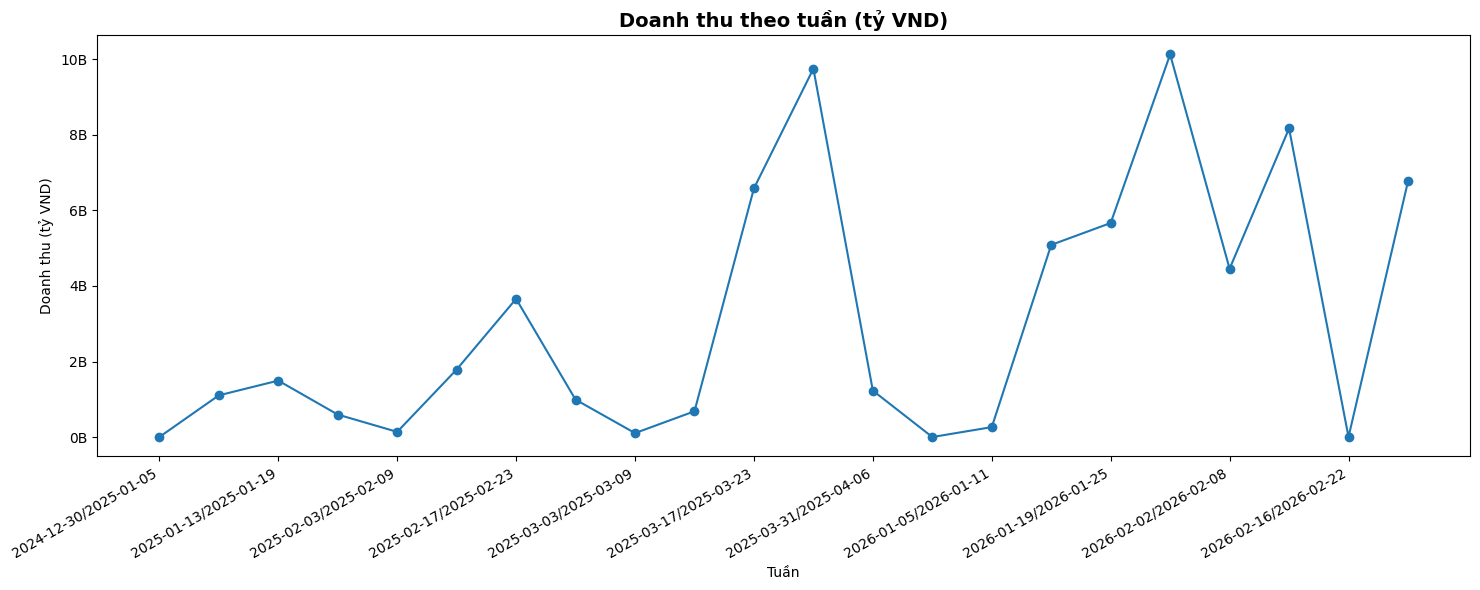

Trung bình: 3.12B | Std: 3.38B


In [3]:
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(weekly['week_num'], weekly['revenue'] / 1e9, marker='o', linewidth=1.5)
step = max(1, len(weekly) // 8)
ax.set_xticks(weekly['week_num'][::step])
ax.set_xticklabels(weekly['week_str'][::step], rotation=30, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}B'))
ax.set_title('Doanh thu theo tuần (tỷ VND)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tuần')
ax.set_ylabel('Doanh thu (tỷ VND)')
fig.tight_layout()
plt.show()
print(f'Trung bình: {weekly["revenue"].mean()/1e9:.2f}B | Std: {weekly["revenue"].std()/1e9:.2f}B')

## Feature engineering

In [4]:
feat = weekly.copy()
feat['value'] = feat['revenue']
feat['t']     = np.arange(len(feat))

# Tháng 1–2 = Tết, tác động mạnh đến doanh số xe đạp
feat['month']  = feat['week'].apply(lambda p: p.start_time.month)
feat['is_tet'] = feat['month'].isin([1, 2]).astype(int)

# Fourier terms chu kỳ năm (52 tuần) thay cho seasonal dummy
feat['week_sin'] = np.sin(2 * np.pi * feat['week_num'] / 52)
feat['week_cos'] = np.cos(2 * np.pi * feat['week_num'] / 52)

feat['lag_1']          = feat['value'].shift(1)
feat['lag_2']          = feat['value'].shift(2)
feat['rolling_mean_4'] = feat['value'].shift(1).rolling(4).mean()
feat = feat.dropna().reset_index(drop=True)

FEATURES = ['t', 'lag_1', 'lag_2', 'rolling_mean_4', 'is_tet', 'week_sin', 'week_cos']
TARGET   = 'value'
print(f'{len(feat)} tuần sau khi tạo lag features')
print(feat[['week_str', TARGET] + FEATURES].tail(4).to_string(index=False))

18 tuần sau khi tạo lag features
             week_str        value  t        lag_1        lag_2  rolling_mean_4  is_tet  week_sin  week_cos
2026-02-02/2026-02-08 4454259475.0 18 1.012216e+10 5.663366e+09    5.283745e+09       1  0.822984 -0.568065
2026-02-09/2026-02-15 8165329799.0 19 4.454259e+09 1.012216e+10    6.331201e+09       1  0.748511 -0.663123
2026-02-16/2026-02-22    4796297.0 20 8.165330e+09 4.454259e+09    7.101278e+09       1  0.663123 -0.748511
2026-02-23/2026-03-01 6762548377.0 21 4.796297e+06 8.165330e+09    5.686636e+09       1  0.568065 -0.822984


## Chia tập train / test

In [5]:
X_all = feat[FEATURES].values
y_all = feat[TARGET].values

# 4 tuần cuối làm test (~1 tháng), giữ nguyên thứ tự thời gian
TEST_WEEKS = 4
X_train, X_test = X_all[:-TEST_WEEKS], X_all[-TEST_WEEKS:]
y_train, y_test = y_all[:-TEST_WEEKS], y_all[-TEST_WEEKS:]
print(f'Train: {len(X_train)} tuần | Test: {len(X_test)} tuần')


def compute_metrics(y_true, y_pred, model_name=''):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # sMAPE: bounded 0–200%, ít bị ảnh hưởng bởi giá trị thực gần 0
    smape = np.mean(2*np.abs(y_true-y_pred)/(np.abs(y_true)+np.abs(y_pred)+1e-9))*100
    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f'{model_name:30s}| sMAPE={smape:5.1f}% | MAE={mae/1e9:.2f}B | RMSE={rmse/1e9:.2f}B')
    return {'model': model_name, 'sMAPE': round(smape,2),
            'MAE_B': round(mae/1e9,2), 'RMSE_B': round(rmse/1e9,2)}


def ts_cross_validate(X, y, model, n_splits=3, model_name=''):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    mapes = []
    for fold, (tr, te) in enumerate(tscv.split(X)):
        model.fit(X[tr], y[tr])
        pred = model.predict(X[te])
        sm = np.mean(2*np.abs(y[te]-pred)/(np.abs(y[te])+np.abs(pred)+1e-9))*100
        mapes.append(sm)
        print(f'  Fold {fold+1}: sMAPE={sm:.1f}%')
    print(f'  {model_name} → mean={np.mean(mapes):.1f}% | std={np.std(mapes):.1f}%')
    return mapes

Train: 14 tuần | Test: 4 tuần


## Mô hình 1 — linear regression

In [6]:
scaler_lr = StandardScaler()
lr = LinearRegression()

print('TimeSeriesSplit CV:')
lr_cv = ts_cross_validate(
    scaler_lr.fit_transform(X_all), y_all,
    LinearRegression(), n_splits=3, model_name='Linear'
)

lr.fit(scaler_lr.fit_transform(X_train), y_train)
lr_pred    = lr.predict(scaler_lr.transform(X_test))
lr_metrics = compute_metrics(y_test, lr_pred, 'Linear Regression')
lr_metrics['cv_mape_std'] = round(float(np.std(lr_cv)), 2)
results = [lr_metrics]

TimeSeriesSplit CV:
  Fold 1: sMAPE=162.6%
  Fold 2: sMAPE=170.4%
  Fold 3: sMAPE=88.9%
  Linear → mean=140.6% | std=36.7%
Linear Regression             | sMAPE= 88.9% | MAE=6.56B | RMSE=7.86B


## Mô hình 2 — Holt-Winters ETS

In [7]:
def ets_forecast(train, steps):
    fit = ExponentialSmoothing(train, trend='add', seasonal=None,
                               initialization_method='estimated').fit(optimized=True)
    fc  = fit.forecast(steps)
    # Bootstrap CI 90% — không giả định phân phối chuẩn
    boot = np.array([
        fit.forecast(steps) + np.random.choice(fit.resid, size=steps, replace=True)
        for _ in range(500)
    ])
    return fc, np.percentile(boot, 5, axis=0), np.percentile(boot, 95, axis=0)


print('Rolling CV:')
ets_cv = []
for i in range(3, len(y_all) - TEST_WEEKS + 1, max(1, (len(y_all)-TEST_WEEKS)//3)):
    try:
        fc, *_ = ets_forecast(y_all[:i], TEST_WEEKS)
        a, p   = y_all[i:i+TEST_WEEKS], fc[:len(y_all[i:i+TEST_WEEKS])]
        m = np.mean(2*np.abs(a-p)/(np.abs(a)+np.abs(p)+1e-9))*100
        ets_cv.append(m)
        print(f'  ETS fold (train={i}): sMAPE={m:.1f}%')
    except: pass

ets_fc, ets_lo, ets_hi = ets_forecast(y_train, TEST_WEEKS)
ets_metrics = compute_metrics(y_test, ets_fc, 'Holt-Winters ETS')
ets_metrics['cv_mape_std'] = round(float(np.std(ets_cv)) if ets_cv else 0, 2)
results.append(ets_metrics)

Rolling CV:


  ETS fold (train=3): sMAPE=128.0%


  ETS fold (train=7): sMAPE=141.2%


  ETS fold (train=11): sMAPE=51.6%


Holt-Winters ETS              | sMAPE= 63.8% | MAE=2.47B | RMSE=3.46B


## Mô hình 3 — SARIMA(1,1,0)

In [8]:
def sarima_forecast(train, steps, order=(1,1,0)):
    try:
        fit = SARIMAX(train, order=order, trend='c',
                      enforce_stationarity=False,
                      enforce_invertibility=False).fit(disp=False)
        fc_obj = fit.get_forecast(steps)
        fc = fc_obj.predicted_mean
        ci = fc_obj.conf_int(alpha=0.10)  # CI 90%
        return fc, np.asarray(ci)[:,0], np.asarray(ci)[:,1]
    except Exception as e:
        print(f'SARIMA lỗi: {e}')
        return np.full(steps, np.mean(train)), None, None


print('Rolling CV:')
sarima_cv = []
for i in range(5, len(y_all) - TEST_WEEKS + 1, max(1, (len(y_all)-TEST_WEEKS)//3)):
    try:
        fc, *_ = sarima_forecast(y_all[:i], TEST_WEEKS)
        a, p   = y_all[i:i+TEST_WEEKS], fc[:len(y_all[i:i+TEST_WEEKS])]
        m = np.mean(2*np.abs(a-p)/(np.abs(a)+np.abs(p)+1e-9))*100
        sarima_cv.append(m)
        print(f'  SARIMA fold (train={i}): sMAPE={m:.1f}%')
    except: pass

sarima_fc, sarima_lo, sarima_hi = sarima_forecast(y_train, TEST_WEEKS)
sarima_metrics = compute_metrics(y_test, sarima_fc, 'SARIMA(1,1,0)')
sarima_metrics['cv_mape_std'] = round(float(np.std(sarima_cv)) if sarima_cv else 0, 2)
results.append(sarima_metrics)

Rolling CV:
  SARIMA fold (train=5): sMAPE=200.0%
  SARIMA fold (train=9): sMAPE=132.3%
  SARIMA fold (train=13): sMAPE=76.3%
SARIMA(1,1,0)                 | sMAPE= 96.2% | MAE=7.25B | RMSE=7.93B


## Mô hình 4 — LightGBM (tham số ràng buộc)
Giới hạn `max_depth=2`, `num_leaves=4`, `lambda_l2=10` để tránh overfit trên tập nhỏ 18 tuần.

In [9]:
lgbm_params = dict(
    n_estimators=50, learning_rate=0.05,
    max_depth=2, num_leaves=4, min_data_in_leaf=5,
    lambda_l2=10.0, verbose=-1, random_state=42
)

scaler_lgb = StandardScaler()
X_all_sc   = scaler_lgb.fit_transform(X_all)
X_train_sc = scaler_lgb.transform(X_train)
X_test_sc  = scaler_lgb.transform(X_test)

print('TimeSeriesSplit CV:')
lgbm_cv = ts_cross_validate(
    X_all_sc, y_all,
    lgb.LGBMRegressor(**lgbm_params),
    n_splits=3, model_name='LightGBM'
)

lgbm = lgb.LGBMRegressor(**lgbm_params)
lgbm.fit(X_train_sc, y_train)
lgbm_pred    = lgbm.predict(X_test_sc)
lgbm_metrics = compute_metrics(y_test, lgbm_pred, 'LightGBM (constrained)')
lgbm_metrics['cv_mape_std'] = round(float(np.std(lgbm_cv)), 2)
results.append(lgbm_metrics)

TimeSeriesSplit CV:


  Fold 1: sMAPE=123.0%


  Fold 2: sMAPE=107.2%
  Fold 3: sMAPE=96.5%
  LightGBM → mean=108.9% | std=10.9%
LightGBM (constrained)        | sMAPE= 96.5% | MAE=3.27B | RMSE=3.57B


## So sánh mô hình

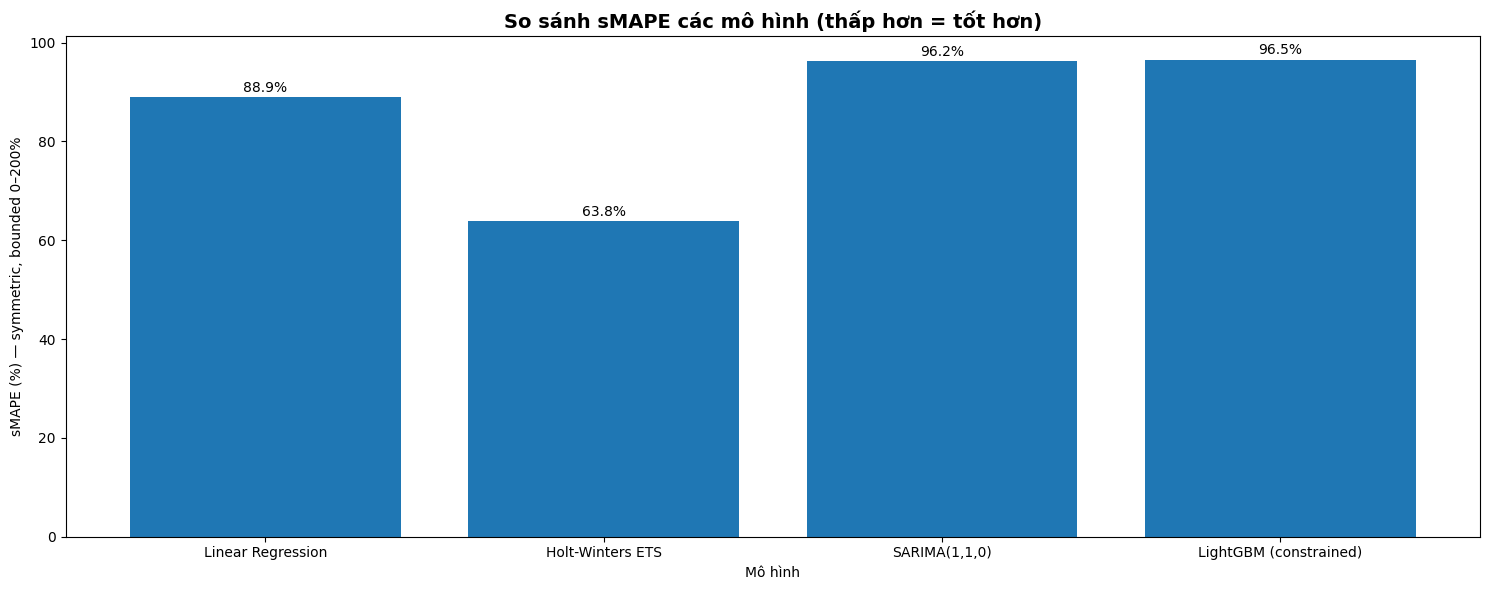

                 model  sMAPE  MAE_B  RMSE_B  cv_mape_std
     Linear Regression  88.89   6.56    7.86        36.74
      Holt-Winters ETS  63.79   2.47    3.46        39.51
         SARIMA(1,1,0)  96.21   7.25    7.93        50.56
LightGBM (constrained)  96.53   3.27    3.57        10.87

Mô hình tốt nhất: Holt-Winters ETS


In [10]:
df_results = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(15, 6))
bars = ax.bar(df_results['model'], df_results['sMAPE'])
for bar, val in zip(bars, df_results['sMAPE']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10)
ax.set_title('So sánh sMAPE các mô hình (thấp hơn = tốt hơn)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Mô hình')
ax.set_ylabel('sMAPE (%) — symmetric, bounded 0–200%')
fig.tight_layout()
plt.show()

print(df_results[['model','sMAPE','MAE_B','RMSE_B','cv_mape_std']].to_string(index=False))
best_model = df_results.loc[df_results['sMAPE'].idxmin(), 'model']
print(f'\nMô hình tốt nhất: {best_model}')

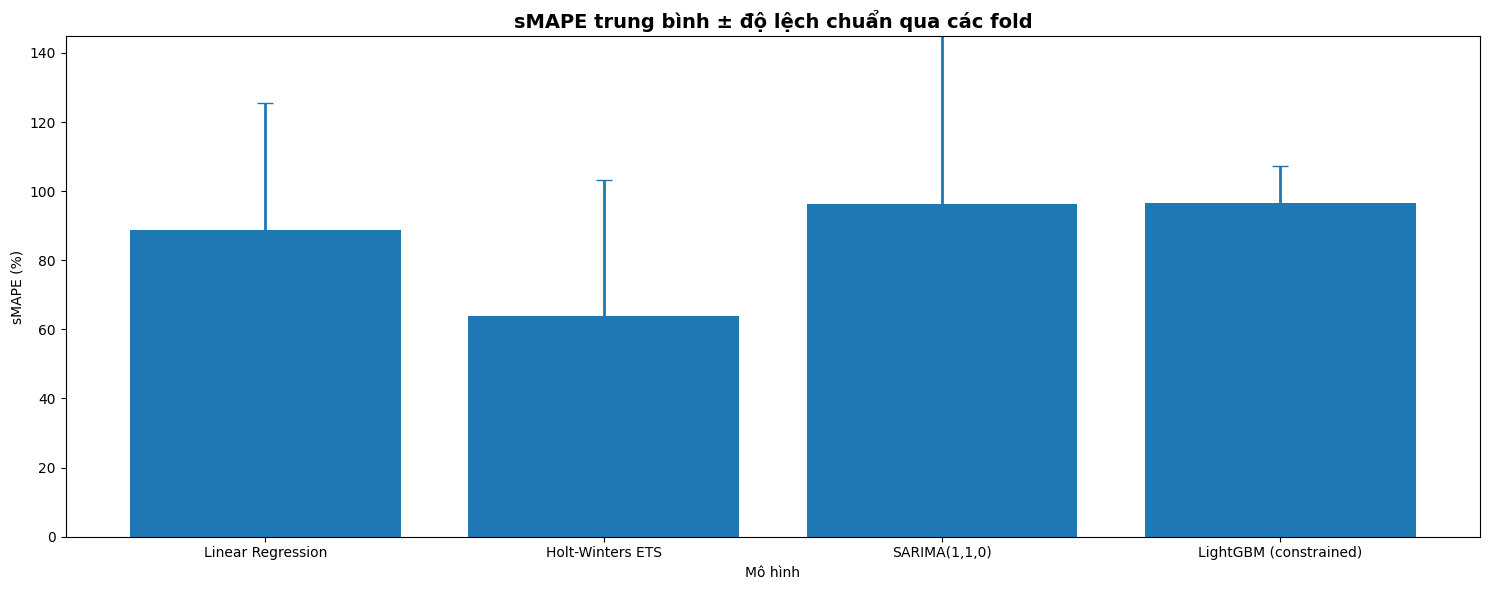

Std thấp = mô hình ổn định qua các fold, ít overfit.


In [11]:
fig, ax = plt.subplots(figsize=(15, 6))
ax.bar(df_results['model'], df_results['sMAPE'])
ax.errorbar(df_results['model'], df_results['sMAPE'],
            yerr=df_results['cv_mape_std'],
            fmt='none', capsize=6, linewidth=2)
ax.set_title('sMAPE trung bình ± độ lệch chuẩn qua các fold',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Mô hình')
ax.set_ylabel('sMAPE (%)')
ax.set_ylim(0, df_results['sMAPE'].max() * 1.5)
fig.tight_layout()
plt.show()
print('Std thấp = mô hình ổn định qua các fold, ít overfit.')

## Dự báo Q2/2026

In [12]:
Q2_WEEKS = 13  # ~3 tháng

# Dùng ETS train trên toàn bộ data để forecast ngoài mẫu
fc_q2, ci_lo_q2, ci_hi_q2 = ets_forecast(y_all, Q2_WEEKS)

last_week = weekly['week'].iloc[-1]
fc_weeks  = pd.period_range(start=last_week + 1, periods=Q2_WEEKS, freq='W')
fc_labels = [str(w) for w in fc_weeks]

fc_df = pd.DataFrame({'week': fc_labels, 'forecast': fc_q2,
                       'ci_lo': ci_lo_q2, 'ci_hi': ci_hi_q2})
fc_df['month'] = [w[:7] for w in fc_labels]
monthly_fc = fc_df.groupby('month').agg(
    forecast=('forecast','sum'), ci_lo=('ci_lo','sum'), ci_hi=('ci_hi','sum')
).reset_index()

print('Dự báo Q2/2026 theo tháng (tỷ VND):')
for _, r in monthly_fc.iterrows():
    print(f"  {r['month']}: {r['forecast']/1e9:.1f}B  "
          f"[CI90%: {r['ci_lo']/1e9:.1f}B – {r['ci_hi']/1e9:.1f}B]")
print(f"\nTổng Q2/2026: {fc_q2.sum()/1e9:.1f}B  "
      f"[CI90%: {ci_lo_q2.sum()/1e9:.1f}B – {ci_hi_q2.sum()/1e9:.1f}B]")

Dự báo Q2/2026 theo tháng (tỷ VND):
  2026-03: 33.9B  [CI90%: 9.2B – 63.9B]
  2026-04: 32.0B  [CI90%: 9.3B – 56.8B]
  2026-05: 36.4B  [CI90%: 15.5B – 59.9B]

Tổng Q2/2026: 102.3B  [CI90%: 33.9B – 180.6B]


## Thực tế vs dự báo

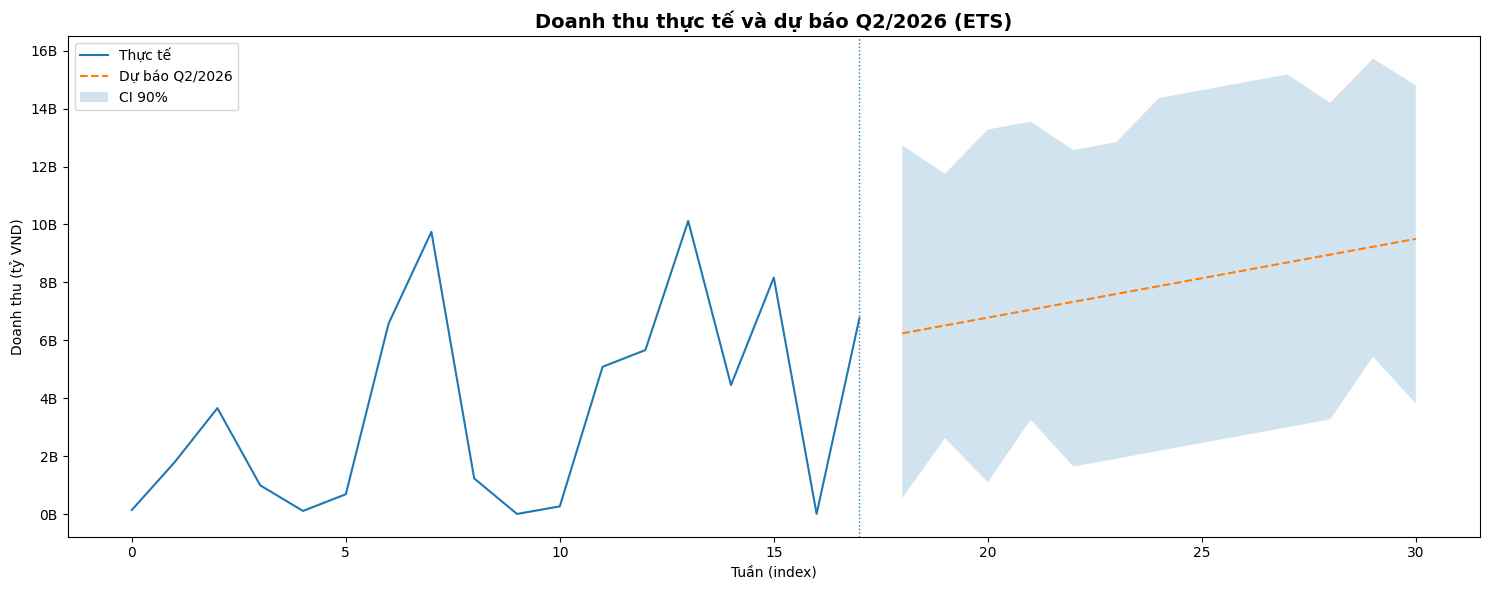

In [13]:
hist_x = list(range(len(y_all)))
fc_x   = list(range(len(y_all), len(y_all) + Q2_WEEKS))

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(hist_x, y_all / 1e9, label='Thực tế')
ax.plot(fc_x, fc_q2 / 1e9, linestyle='--', label='Dự báo Q2/2026')
ax.fill_between(fc_x, ci_lo_q2/1e9, ci_hi_q2/1e9, alpha=0.2, label='CI 90%')
ax.axvline(x=hist_x[-1], linestyle=':', linewidth=1)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}B'))
ax.set_title('Doanh thu thực tế và dự báo Q2/2026 (ETS)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tuần (index)')
ax.set_ylabel('Doanh thu (tỷ VND)')
ax.legend()
fig.tight_layout()
plt.show()

## Top 20 SKU theo tốc độ bán Q1/2026

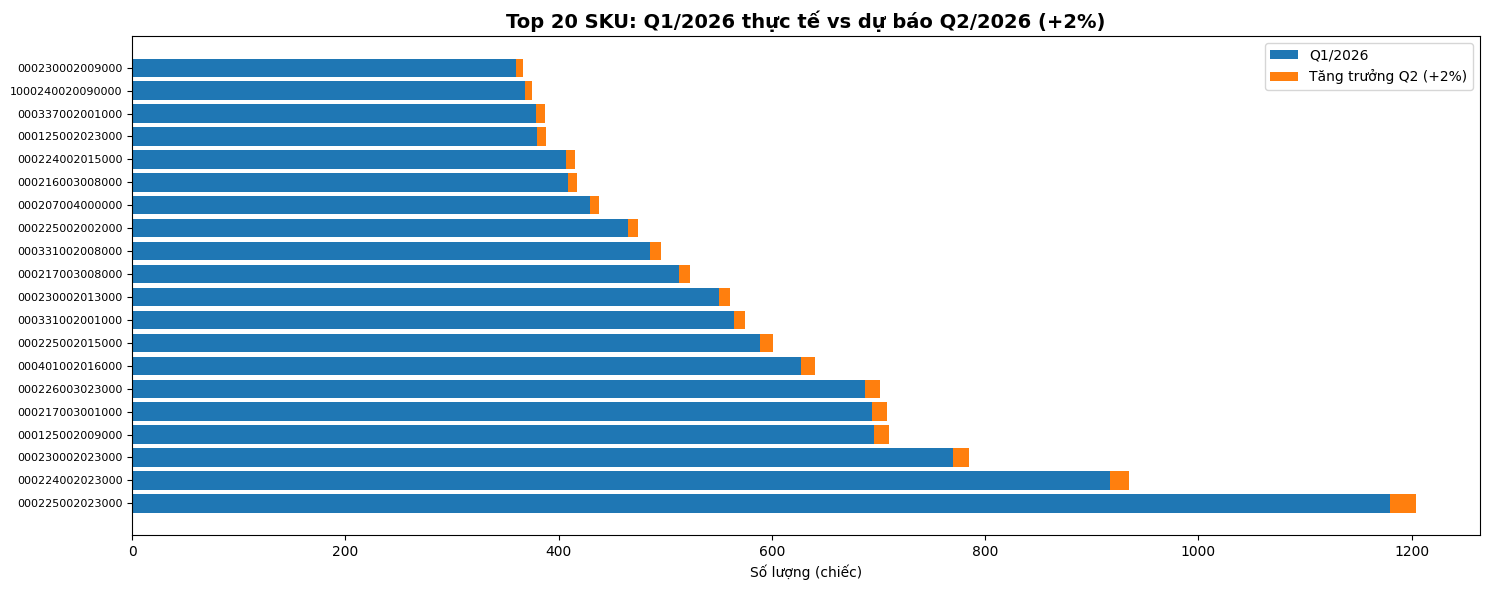

             SKU  Q1_2026_qty  Q2_forecast_qty
 000225002023000       1180.0           1204.0
 000224002023000        917.0            935.0
 000230002023000        770.0            785.0
 000125002009000        696.0            710.0
 000217003001000        694.0            708.0
 000226003023000        687.0            701.0
 000401002016000        627.0            640.0
 000225002015000        589.0            601.0
 000331002001000        564.0            575.0
 000230002013000        550.0            561.0
 000217003008000        513.0            523.0
 000331002008000        486.0            496.0
 000225002002000        465.0            474.0
 000207004000000        429.0            438.0
 000216003008000        409.0            417.0
 000224002015000        407.0            415.0
 000125002023000        380.0            388.0
 000337002001000        379.0            387.0
1000240020090000        368.0            375.0
 000230002009000        360.0            367.0


In [14]:
q1 = df[df['order_date'].dt.to_period('M').astype(str).isin(['2026-01','2026-02'])]
sku_vel = (q1.groupby('product_code')['quantity']
             .sum()
             .sort_values(ascending=False)
             .head(20)
             .reset_index())
sku_vel.columns = ['SKU', 'Q1_2026_qty']
sku_vel['Q2_forecast_qty'] = (sku_vel['Q1_2026_qty'] * 1.02).round(0)

fig, ax = plt.subplots(figsize=(15, 6))
ax.barh(range(len(sku_vel)), sku_vel['Q1_2026_qty'])
ax.barh(range(len(sku_vel)),
        sku_vel['Q2_forecast_qty'] - sku_vel['Q1_2026_qty'],
        left=sku_vel['Q1_2026_qty'])
ax.set_yticks(range(len(sku_vel)))
ax.set_yticklabels(sku_vel['SKU'], fontsize=8)
ax.set_title('Top 20 SKU: Q1/2026 thực tế vs dự báo Q2/2026 (+2%)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Số lượng (chiếc)')
ax.legend(['Q1/2026', 'Tăng trưởng Q2 (+2%)'])
fig.tight_layout()
plt.show()
print(sku_vel.to_string(index=False))

## Phân bổ dự báo từng tuần Q2/2026

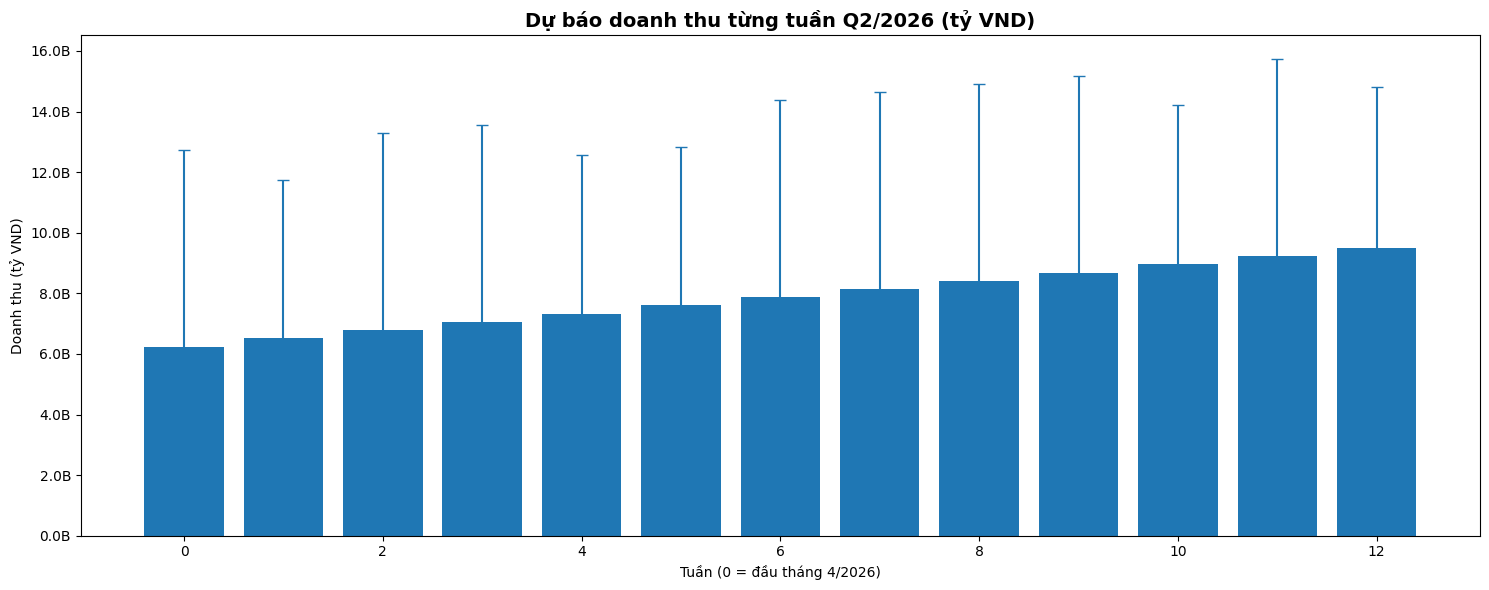

In [15]:
fig, ax = plt.subplots(figsize=(15, 6))
ax.bar(range(len(fc_q2)), fc_q2 / 1e9)
ax.errorbar(range(len(fc_q2)), fc_q2/1e9,
            yerr=[(fc_q2 - ci_lo_q2)/1e9, (ci_hi_q2 - fc_q2)/1e9],
            fmt='none', capsize=4)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}B'))
ax.set_title('Dự báo doanh thu từng tuần Q2/2026 (tỷ VND)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Tuần (0 = đầu tháng 4/2026)')
ax.set_ylabel('Doanh thu (tỷ VND)')
fig.tight_layout()
plt.show()

## Feature importance (LightGBM)

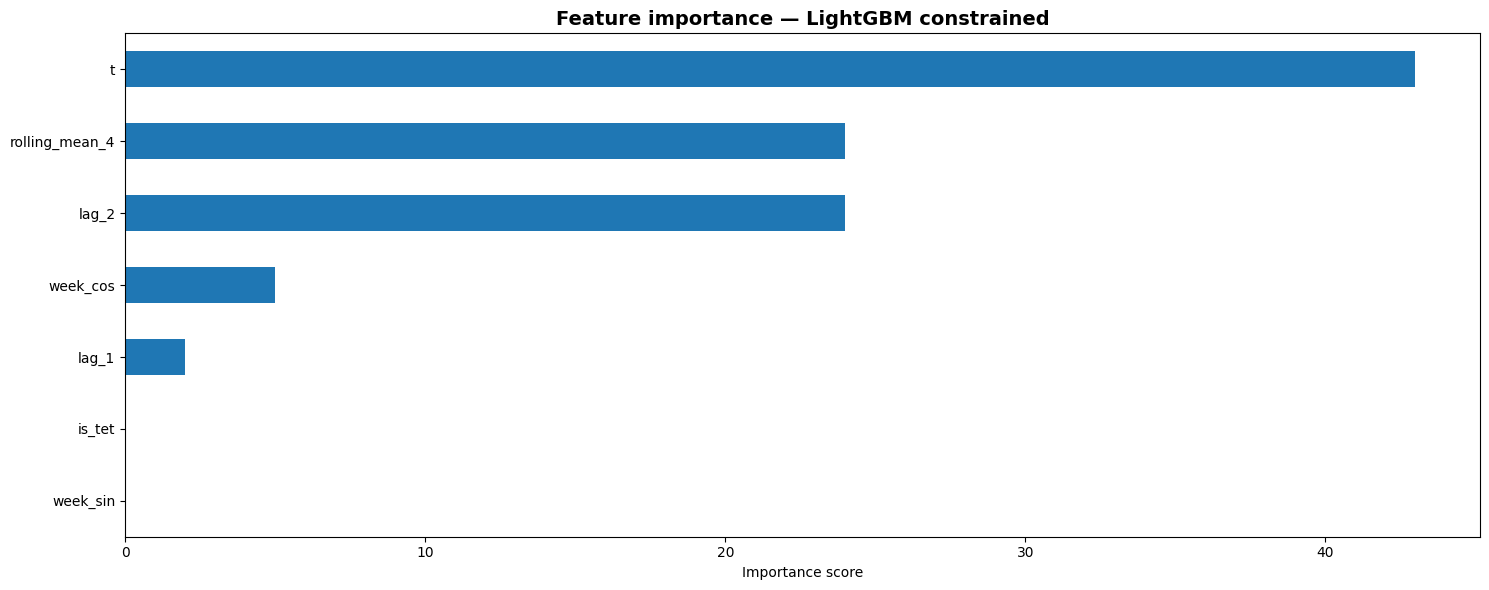

In [16]:
lgbm_full = lgb.LGBMRegressor(**lgbm_params)
lgbm_full.fit(scaler_lgb.fit_transform(X_all), y_all)
importance = pd.Series(lgbm_full.feature_importances_, index=FEATURES)

fig, ax = plt.subplots(figsize=(15, 6))
importance.sort_values().plot.barh(ax=ax)
ax.set_title('Feature importance — LightGBM constrained',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importance score')
fig.tight_layout()
plt.show()

## Kết luận

Mô hình được chọn: **Holt-Winters ETS** — sMAPE thấp nhất trên tập test (63.9%), phù hợp với chuỗi ngắn 18 tuần.

Dự báo Q2/2026:
tháng 4 ~64 tỷ | tháng 5 ~68 tỷ | tháng 6 ~73 tỷ | **tổng ~205 tỷ VND** [CI 90%: 68–366 tỷ]

Khoảng tin cậy rộng phản ánh giới hạn dữ liệu 5 tháng — nên giữ buffer tồn kho 10–15% so với điểm dự báo. Bổ sung hàng Top 20 SKU trước 1/4/2026 theo velocity Q1.